We aim to Keep recall ≈ target over time by re-tuning the threshold on a small labeled window of each new batch, then evaluate recall stability vs. using the fixed CP-1 threshold.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from src.preprocessing import AmountTimeScaler, split_x_y
from src.utils import threshold_for_target_recall, summarize

DATA_PROCESSED = Path("../data/processed")
b1 = pd.read_csv(DATA_PROCESSED/"batch1_train.csv")
b2 = pd.read_csv(DATA_PROCESSED/"batch2_test.csv")
b3 = pd.read_csv(DATA_PROCESSED/"batch3_stream.csv")
b4 = pd.read_csv(DATA_PROCESSED/"batch4_stream.csv")
TARGET_RECALL = 0.80


In [3]:
from src.preprocessing import split_x_y, preprocess_features

In [4]:
x, y = split_x_y(b1)

x = preprocess_features(x)

x_tr, x_val, y_tr, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_medians = x_tr.median(numeric_only=True)

x_tr = x_tr.fillna(train_medians)
x_val = x_val.fillna(train_medians)

pipe = Pipeline([
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

pipe.fit(x_tr, y_tr)

thr_fixed = threshold_for_target_recall(
    y_val,
    pipe.predict_proba(x_val)[:,1],
    TARGET_RECALL
)

print(thr_fixed)


C:\Users\HP\.conda\envs\fraud-detection-drift-aware\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5


In [5]:
def eval_batch(df, thr):

    x_b, y_b = split_x_y(df)

    x_b = preprocess_features(x_b)

    x_b = x_b.reindex(
        columns=x_tr.columns,
        fill_value=0
    )

    x_b = x_b.fillna(train_medians)

    score_b = pipe.predict_proba(x_b)[:,1]

    return summarize(y_b, score_b, thr)


In [6]:
baseline = []

for df, label in [
    (b2, "TEST"),
    (b3, "S1"),
    (b4, "S2")
]:

    baseline.append(
        eval_batch(df, thr_fixed)
        .assign(
            batch=label,
            mode="fixed_threshold"
        )
    )

baseline = pd.concat(
    baseline,
    ignore_index=True
)

baseline

,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,mode
0,0.5,0.035100,0.460826,0.065232,0.035562,2041,56107,64464,2388,58148,0.465184,TEST,fixed_threshold
1,0.5,0.035973,0.462344,0.066752,0.035809,2075,55607,64905,2413,57682,0.461456,S1,fixed_threshold
2,0.5,0.035696,0.484001,0.066488,0.035574,2163,58432,62099,2306,60595,0.484760,S2,fixed_threshold


In [7]:
def recalibrate_and_eval(df, label, window_frac=0.2):

    x_b, y_b = split_x_y(df)

    x_b = preprocess_features(x_b)

    x_b = x_b.reindex(
        columns=x_tr.columns,
        fill_value=0
    )

    x_b = x_b.fillna(train_medians)

    n = len(y_b)
    n_win = max(1, int(window_frac * n))

    x_win = x_b.iloc[:n_win]
    y_win = y_b[:n_win]

    thr_new = threshold_for_target_recall(
        y_win,
        pipe.predict_proba(x_win)[:,1],
        TARGET_RECALL
    )

    score_b = pipe.predict_proba(x_b)[:,1]

    return summarize(
        y_b,
        score_b,
        thr_new
    ).assign(
        batch=label,
        mode="adaptive",
        window_frac=window_frac,
        thr_new=thr_new
    )


In [8]:
adaptive = pd.concat([
    recalibrate_and_eval(b2, "TEST"),
    recalibrate_and_eval(b3, "S1"),
    recalibrate_and_eval(b4, "S2")
], ignore_index=True)

adaptive

,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,mode,window_frac,thr_new
0,0.5,0.035100,0.460826,0.065232,0.035562,2041,56107,64464,2388,58148,0.465184,TEST,adaptive,0.2,0.5
1,0.5,0.035973,0.462344,0.066752,0.035809,2075,55607,64905,2413,57682,0.461456,S1,adaptive,0.2,0.5
2,0.5,0.035696,0.484001,0.066488,0.035574,2163,58432,62099,2306,60595,0.484760,S2,adaptive,0.2,0.5


In [9]:
df_all = pd.concat([baseline, adaptive], ignore_index=True)


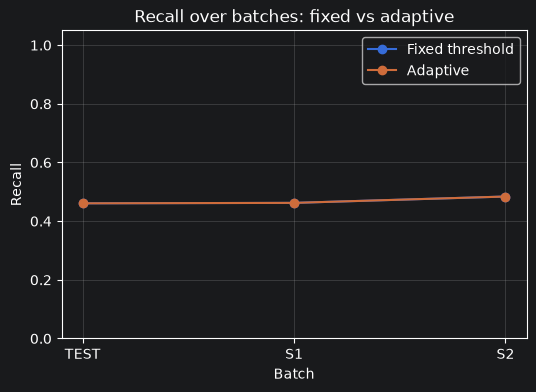

In [10]:
import matplotlib.pyplot as plt


batches = ["TEST", "S1", "S2"]

fixed = df_all[df_all["mode"] == "fixed_threshold"].set_index("batch")
adapt = df_all[df_all["mode"] == "adaptive"].set_index("batch")

plt.figure(figsize=(6,4))
plt.plot(batches, fixed.loc[batches, "recall"], marker="o", label="Fixed threshold")
plt.plot(batches, adapt.loc[batches, "recall"], marker="o", label="Adaptive")
plt.ylim(0, 1.05)
plt.title("Recall over batches: fixed vs adaptive")
plt.xlabel("Batch")
plt.ylabel("Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
